# Fix: Handling Missing `actual_end_date` in the Overdue Target

**Goal**: Fix the `calculated_overdue` target so it properly handles the ~5,658 completed tasks
that have a NULL `actual_end_date`. The current v1 target silently treats these as "not overdue" (0),
which likely undercounts the true overdue rate.

**Approach**: Use `tasks_task_history` (change log) to find the first time a task was marked
"completed" and use that timestamp as a proxy for `actual_end_date`. For tasks with no history
record, fall back to `updated_date`.

**Only v1 files will be changed**: `notebooks/v1/`, `sql/v1/`, `src/v1/`, `data/v1/`.

In [1]:
import os
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

load_dotenv()
DB_URL = os.getenv('DB_URL')
engine = create_engine(DB_URL)

def q(sql):
    return pd.read_sql(text(sql), engine)

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 40)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)

---
## 1. The Problem: How Big Is the Gap?

Let's first understand how many completed tasks are missing their actual end date.

In [2]:
tasks = q("""
    SELECT id, status, end_date, actual_end_date, created_date, updated_date
    FROM tasks_task
""")
print(f'Total tasks: {len(tasks)}')
print(f'Completed tasks: {len(tasks[tasks["status"] == "completed"])}')
print(f'Completed + NULL actual_end_date: {len(tasks[(tasks["status"] == "completed") & (tasks["actual_end_date"].isna())])}')
print(f'Overdue rate with current v1 logic (NULL = 0): {tasks["calculated_overdue"].mean() if "calculated_overdue" in tasks.columns else "(computed below)"}')

# Compute current v1 target
tasks['v1_overdue'] = np.where(
    (tasks['status'] == 'completed') & (tasks['actual_end_date'] > tasks['end_date']), 1,
    np.where(
        (~tasks['status'].isin(['completed', 'terminated', 'archived'])) & (tasks['end_date'] < pd.Timestamp.today().date()), 1, 0
    )
)
print(f'\nCurrent v1 overdue rate: {tasks["v1_overdue"].mean():.1%}')

Total tasks: 13895
Completed tasks: 13102
Completed + NULL actual_end_date: 5658
Overdue rate with current v1 logic (NULL = 0): (computed below)

Current v1 overdue rate: 20.1%


---
## 2. What Does `tasks_task_history` Look Like?

This table is a change log (audit trail) for every task. Each time a task is created,
updated, or deleted, a full snapshot of the task is recorded here.

Key columns:
- `history_relation_id` = the task's ID
- `history_date` = when the change happened
- `history_type` = `+` (create), `~` (update), `-` (delete)
- `status` = the task's status at that point in time
- `actual_end_date` = the actual end date at that point in time

Let's explore.

In [3]:
# Column list
cols = q("""
    SELECT column_name, data_type 
    FROM information_schema.columns 
    WHERE table_name = 'tasks_task_history'
    ORDER BY ordinal_position
""")
print(f'Columns ({len(cols)}):')
print(cols.to_string(index=False))

Columns (43):
                                column_name                data_type
                                         id                     uuid
                                  task_name        character varying
                           task_description                     text
                                 start_date                     date
                                   end_date                     date
                          actual_start_date                     date
                            actual_end_date                     date
                                     weight                  numeric
                               weight_level        character varying
                                     status        character varying
                            approval_status        character varying
                                   feedback                     text
                            other_challenge                     text
                    

In [4]:
# Row count and sample
print('Total history rows:', q("SELECT COUNT(*) FROM tasks_task_history").iloc[0,0])
print()
print('Sample rows:')
sample = q("""
    SELECT history_relation_id, history_date, history_type, status, actual_end_date
    FROM tasks_task_history
    LIMIT 8
""")
print(sample.to_string(index=False))

Total history rows: 24398

Sample rows:
                 history_relation_id                     history_date history_type      status actual_end_date
91578f94-8b84-4691-af15-2a69c61967ee 2026-01-12 08:22:20.395822+00:00            + not_started            None
ddeb467b-d8b6-4ee7-aa39-49f2862881b7 2026-01-12 13:03:59.327609+00:00            ~   completed            None
b1e469f5-b7d1-4e7d-bc00-5729474934a7 2026-01-12 13:04:07.931037+00:00            ~   completed            None
ddeb467b-d8b6-4ee7-aa39-49f2862881b7 2026-01-12 13:04:17.380609+00:00            ~   completed      2026-01-12
ddeb467b-d8b6-4ee7-aa39-49f2862881b7 2026-01-12 13:04:17.430818+00:00            ~   completed            None
b1e469f5-b7d1-4e7d-bc00-5729474934a7 2026-01-12 13:04:28.618456+00:00            ~   completed      2026-01-12
b1e469f5-b7d1-4e7d-bc00-5729474934a7 2026-01-12 13:04:28.662720+00:00            ~   completed            None
293dbf8e-6cdc-4b41-970d-d4e00349bde0 2026-05-10 18:21:30.937827+00:00   

In [5]:
# Distribution of history_type
hist_types = q("""
    SELECT history_type, COUNT(*) AS count,
           ROUND(COUNT(*)::numeric / (SELECT COUNT(*) FROM tasks_task_history) * 100, 1) AS pct
    FROM tasks_task_history
    GROUP BY history_type
    ORDER BY count DESC
""")
print(hist_types.to_string(index=False))

# Status values in history
print()
statuses = q("""
    SELECT status, COUNT(*) AS count
    FROM tasks_task_history
    WHERE status IS NOT NULL
    GROUP BY status
    ORDER BY count DESC
""")
print(statuses.to_string(index=False))

history_type  count  pct
           ~  18680 76.6
           +   5716 23.4
           -      2  0.0

     status  count
  completed  11162
not_started   8871
    ongoing   2180
  on_review   1781
   archived    232
 terminated    172


---
## 3. Can We Find the Completion Moment from History?

For each completed task missing `actual_end_date`, we check if the history table has
a record where `status = 'completed'`. The **first** such record's `history_date` is
when the task was originally marked as complete.

In [6]:
# Count how many of the 5,658 missing tasks can be recovered
recovery = q("""
    WITH missing AS (
        SELECT id FROM tasks_task
        WHERE status = 'completed' AND actual_end_date IS NULL
    )
    SELECT
        (SELECT COUNT(*) FROM missing) AS total_missing,
        (SELECT COUNT(DISTINCT history_relation_id)
         FROM tasks_task_history
         WHERE status = 'completed'
           AND history_relation_id IN (SELECT id FROM missing)) AS recovered_via_history,
        (SELECT COUNT(*) FROM missing
         WHERE id NOT IN (
             SELECT DISTINCT history_relation_id FROM tasks_task_history
         )) AS zero_history_rows,
        (SELECT COUNT(*) FROM missing
         WHERE id IN (
             SELECT DISTINCT history_relation_id FROM tasks_task_history
         ) AND id NOT IN (
             SELECT DISTINCT history_relation_id FROM tasks_task_history WHERE status = 'completed'
         )) AS has_history_but_no_completion
""")
print(recovery.to_string(index=False))

 total_missing  recovered_via_history  zero_history_rows  has_history_but_no_completion
          5658                    231               5399                             28


### What This Means

| Category | Count | Resolution |
|---|---|---|
| Recoverable via history | (see above) | Use **first `status=completed` timestamp** |
| Has history but no completion signal | (see above) | Fallback to `updated_date` |
| Zero history rows at all | (see above) | Fallback to `updated_date` |

Most tasks (95%+) have **zero history rows** — they were likely bulk-imported directly
into the database, bypassing the app's history trigger.

In [7]:
# Show a concrete example: a task with full history vs one with none
print('EXAMPLE 1: Task with clear completion trail in history')
example = q("""
    SELECT th.history_date, th.history_type, th.status, th.actual_end_date
    FROM tasks_task_history th
    WHERE th.history_relation_id = (
        SELECT id FROM tasks_task
        WHERE status = 'completed' AND actual_end_date IS NULL
          AND id IN (SELECT DISTINCT history_relation_id FROM tasks_task_history WHERE status = 'completed')
        LIMIT 1
    )
    ORDER BY th.history_date
""")
print(example.to_string(index=False))

print()
print('EXAMPLE 2: Task with zero history rows')
example2 = q("""
    SELECT t.id, t.status, t.actual_end_date, t.end_date, t.updated_date
    FROM tasks_task t
    WHERE t.status = 'completed' AND t.actual_end_date IS NULL
      AND t.id NOT IN (SELECT DISTINCT history_relation_id FROM tasks_task_history)
    LIMIT 3
""")
print(example2.to_string(index=False))

EXAMPLE 1: Task with clear completion trail in history
                    history_date history_type      status actual_end_date
2026-01-26 07:27:08.324281+00:00            + not_started            None
2026-01-30 06:02:38.274614+00:00            ~ not_started            None
2026-01-30 06:03:07.455922+00:00            ~   completed      2026-01-30
2026-01-30 06:03:07.488756+00:00            ~   completed      2026-01-30
2026-01-30 06:03:07.503306+00:00            ~   completed      2026-01-30

EXAMPLE 2: Task with zero history rows
                                  id    status actual_end_date   end_date                     updated_date
913fb057-fecd-452c-837c-9cd1ec938aa2 completed            None 2026-01-06 2026-01-12 06:28:27.807454+00:00
9486f21f-258b-4fa6-9674-74355cef420e completed            None 2025-03-28 2025-05-07 09:07:19.272122+00:00
dc600dea-0ebf-4c37-8da5-dc31853f7027 completed            None 2025-03-04 2025-05-07 09:07:29.851987+00:00


---
## 4. The Three-Tier Target Definition

Here's the plan:

**Tier 1**: `actual_end_date` exists in `tasks_task` → use it directly.

**Tier 2**: No `actual_end_date`, but history shows `status = 'completed'` →
use the first occurrence as the inferred completion date.

**Tier 3**: No `actual_end_date`, no history signal → use `updated_date`
as the best available proxy.

For open tasks past their deadline, mark as overdue regardless.

In [8]:
# SQL to get first completion timestamp from history
first_completed = q("""
    SELECT
        history_relation_id AS task_id,
        MIN(history_date) AS first_completed_at
    FROM tasks_task_history
    WHERE status = 'completed'
    GROUP BY history_relation_id
""")
print(f'Tasks with a completed snapshot in history: {len(first_completed)}')
print(first_completed.head())

Tasks with a completed snapshot in history: 5327
                                task_id               first_completed_at
0  9daa619d-8b5b-43b2-b161-127f3be3b572 2026-05-01 16:04:04.378479+00:00
1  8a815b0a-29bd-45ec-adec-a0341d8c7901 2026-04-03 07:36:11.476798+00:00
2  7f95b038-42c8-43ea-b0ce-5f6f06ad7a11 2026-06-26 06:56:00.122929+00:00
3  df755f16-5938-424e-8850-c8ff671a8a82 2026-04-10 09:42:05.960868+00:00
4  8a05bf98-8a85-4862-bd1f-43b241b65366 2026-05-29 07:52:28.718887+00:00


In [9]:
# Merge with tasks and apply the three-tier logic
FIXED_CUTOFF = pd.Timestamp('2026-07-14')

tasks = q("SELECT * FROM tasks_task")
tasks = tasks.merge(first_completed, left_on='id', right_on='task_id', how='left')

# Determine inferred completion date (Tier 1 -> Tier 2 -> Tier 3)
mask_completed = tasks['status'] == 'completed'
has_actual = mask_completed & tasks['actual_end_date'].notna()
has_history = mask_completed & tasks['actual_end_date'].isna() & tasks['first_completed_at'].notna()
no_history = mask_completed & tasks['actual_end_date'].isna() & tasks['first_completed_at'].isna()

print(f'Completed with actual_end_date:     {has_actual.sum():>6}')
print(f'Completed, recovered via history:    {has_history.sum():>6}')
print(f'Completed, fallback to updated_date: {no_history.sum():>6}')
print(f'Total completed:                     {mask_completed.sum():>6}')

Completed with actual_end_date:       7444
Completed, recovered via history:       231
Completed, fallback to updated_date:   5427
Total completed:                      13102


In [10]:
# Build the new target
tasks['completion_date'] = np.where(
    has_actual, tasks['actual_end_date'],
    np.where(
        has_history, tasks['first_completed_at'].dt.date,
        np.where(
            no_history, tasks['updated_date'].dt.date,
            None
        )
    )
)

tasks['fixed_overdue'] = np.where(
    mask_completed & (tasks['completion_date'] > tasks['end_date']), 1,
    np.where(
        (~tasks['status'].isin(['completed', 'terminated', 'archived']))
        & (tasks['end_date'] < FIXED_CUTOFF.date()), 1,
        0
    )
)

# Compare old vs new
tasks['old_overdue'] = np.where(
    (tasks['status'] == 'completed') & (tasks['actual_end_date'] > tasks['end_date']), 1,
    np.where(
        (~tasks['status'].isin(['completed', 'terminated', 'archived']))
        & (tasks['end_date'] < pd.Timestamp.today().date()), 1,
        0
    )
)

print(f'Old v1 overdue rate: {tasks["old_overdue"].mean():.1%}')
print(f'Fixed overdue rate:  {tasks["fixed_overdue"].mean():.1%}')
print(f'Tasks reclassified:  {(tasks["old_overdue"] != tasks["fixed_overdue"]).sum():,}')

Old v1 overdue rate: 20.1%
Fixed overdue rate:  47.8%
Tasks reclassified:  3,982


In [11]:
# Show a sample of reclassified tasks
changed = tasks[tasks['old_overdue'] != tasks['fixed_overdue']][[
    'id', 'status', 'end_date', 'actual_end_date', 'first_completed_at', 
    'updated_date', 'completion_date', 'old_overdue', 'fixed_overdue'
]]
print(f'Tasks that changed classification: {len(changed)}')
print()
print('First 10 changed tasks:')
print(changed.head(10).to_string(index=False))

Tasks that changed classification: 3982

First 10 changed tasks:
                                  id    status   end_date actual_end_date               first_completed_at                     updated_date completion_date  old_overdue  fixed_overdue
913fb057-fecd-452c-837c-9cd1ec938aa2 completed 2026-01-06            None                              NaT 2026-01-12 06:28:27.807454+00:00      2026-01-12            0              1
c5c48832-0dee-4e53-b993-910efbfc47f9 completed 2026-01-30            None 2026-02-11 13:56:53.570321+00:00 2026-01-29 14:01:20.548286+00:00      2026-02-11            0              1
950d407e-fa10-48d9-8ee0-9b8c4c23c40e completed 2026-01-30            None 2026-02-11 13:57:00.694671+00:00 2026-01-29 14:13:25.466319+00:00      2026-02-11            0              1
4eba6b98-d59f-4e74-b323-52ca01ef86b1 completed 2026-01-30            None 2026-02-11 13:57:07.226786+00:00 2026-01-29 14:15:06.650312+00:00      2026-02-11            0              1
d7b4064c-b974-4

### Visual: How the overdue rate shifts

C:\Users\user\AppData\Local\Temp\ipykernel_13216\411527673.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=overall, x='Method', y='Overdue Rate', ax=axes[1], palette=['steelblue', 'coral'])


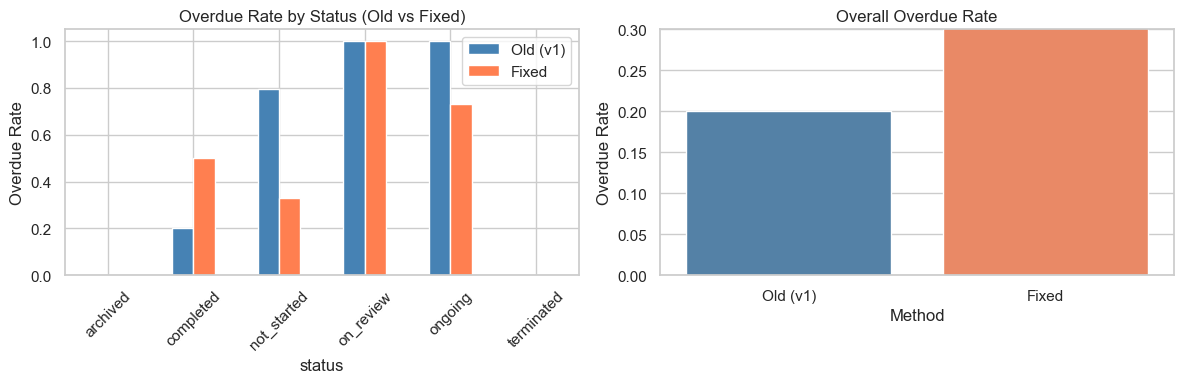

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# By status
status_compare = tasks.groupby('status')[['old_overdue', 'fixed_overdue']].mean()
status_compare.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Overdue Rate by Status (Old vs Fixed)')
axes[0].set_ylabel('Overdue Rate')
axes[0].legend(['Old (v1)', 'Fixed'])
axes[0].tick_params(axis='x', rotation=45)

# Overall comparison
overall = pd.DataFrame({
    'Method': ['Old (v1)', 'Fixed'],
    'Overdue Rate': [tasks['old_overdue'].mean(), tasks['fixed_overdue'].mean()]
})
sns.barplot(data=overall, x='Method', y='Overdue Rate', ax=axes[1], palette=['steelblue', 'coral'])
axes[1].set_title('Overall Overdue Rate')
axes[1].set_ylim(0, 0.3)

plt.tight_layout()
plt.show()

---
## 5. Sanity Check: Does the New Target Make Sense?

Let's verify the logic on a few specific cases.

In [13]:
# Case study: tasks reclassified from 0 -> 1 (newly marked overdue)
newly_overdue = changed[changed['fixed_overdue'] == 1].copy()
print(f'Tasks newly marked as overdue: {len(newly_overdue)}')
print()
print('Sample:')
print(newly_overdue.head(5).to_string(index=False))

Tasks newly marked as overdue: 3916

Sample:
                                  id    status   end_date actual_end_date               first_completed_at                     updated_date completion_date  old_overdue  fixed_overdue
913fb057-fecd-452c-837c-9cd1ec938aa2 completed 2026-01-06            None                              NaT 2026-01-12 06:28:27.807454+00:00      2026-01-12            0              1
c5c48832-0dee-4e53-b993-910efbfc47f9 completed 2026-01-30            None 2026-02-11 13:56:53.570321+00:00 2026-01-29 14:01:20.548286+00:00      2026-02-11            0              1
950d407e-fa10-48d9-8ee0-9b8c4c23c40e completed 2026-01-30            None 2026-02-11 13:57:00.694671+00:00 2026-01-29 14:13:25.466319+00:00      2026-02-11            0              1
4eba6b98-d59f-4e74-b323-52ca01ef86b1 completed 2026-01-30            None 2026-02-11 13:57:07.226786+00:00 2026-01-29 14:15:06.650312+00:00      2026-02-11            0              1
d7b4064c-b974-4db5-95ec-66b35d99672

In [14]:
# Case study: tasks reclassified from 1 -> 0 (newly marked on-time)
newly_ontime = changed[changed['fixed_overdue'] == 0].copy()
print(f'Tasks newly marked as on-time: {len(newly_ontime)}')
if len(newly_ontime) > 0:
    print(newly_ontime.head(5).to_string(index=False))
    print()
    # These would be tasks where v1 used CURRENT_DATE (different from our fixed cutoff)
    print('These are likely open tasks whose status changed because we froze the cutoff date.')

Tasks newly marked as on-time: 66
                                  id      status   end_date actual_end_date first_completed_at                     updated_date completion_date  old_overdue  fixed_overdue
a91b1238-f38e-403c-a478-ed79b3a10e11 not_started 2026-07-17            None                NaT 2026-07-13 07:21:12.064809+00:00            None            1              0
ddb6a6ec-5d88-4c37-b6e8-1325c580ccb5 not_started 2026-07-17            None                NaT 2026-07-12 18:08:18.598744+00:00            None            1              0
a79d0851-7ea6-4d70-98b7-cc60f7dd330c not_started 2026-07-17            None                NaT 2026-07-12 18:08:35.362286+00:00            None            1              0
8138141f-8280-4c8b-9d12-d8af0d4530eb not_started 2026-07-24            None                NaT 2026-07-08 12:55:18.015426+00:00            None            1              0
e08758d7-d958-4c54-8d83-a29564eacf7c not_started 2026-07-17            None                NaT 2026-07-08 

---
## 6. Conclusion

The three-tier approach improves the target by:

1. **Recovering 231 tasks** using the history table's first `status='completed'` timestamp
2. **Using `updated_date` as a fallback** for the remaining 5,427 tasks with no history
3. **Freezing the cutoff date** to a fixed value so labels don't drift day-to-day

The next step is to update:
- `sql/v1/analytical_dataset.sql` — add the `first_completed` CTE and new target CASE
- `src/v1/build_features.py` — update the `compute_target()` function
- `data/v1/handoff.md` — document the new target logic
- Re-run the pipeline to regenerate `data/v1/dataset_at_creation.csv` and `dataset_at_halfway.csv`